# Kaggle Competition Code 

# Import Package

In [1]:
# imports and setup
%matplotlib inline

#data processing
import numpy as np
import pandas as pd
from numpy import mean
from numpy import std
from sklearn.model_selection import train_test_split

#scaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

#plot
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

#hyperparameter tuning
from skopt import BayesSearchCV
from skopt.space import Real,Categorical,Integer

#Algorithm
# multinomial regression
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn import datasets
#classification tree
import graphviz
from six import StringIO
import pydotplus
from IPython.display import Image

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz

#bagging #Random forest #Boosting
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

#XGBoost
from sklearn.pipeline import Pipeline
from category_encoders.target_encoder import TargetEncoder
# from sklearn.preprocessing import TargetEncoder

from xgboost import XGBClassifier

#measure
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, mean_squared_error


#CV
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold


pd.set_option('display.precision', 4) # number precision for pandas
pd.set_option('display.max_rows', 10)
pd.set_option('display.float_format', '{:20,.2f}'.format) # get rid of scientific notation

# load and summarize the dataset
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import LabelEncoder

df_train =  pd.read_csv('data/train_data.csv') #restart
df_train
df_test = pd.read_csv('data/test_data.csv') 


ModuleNotFoundError: No module named 'skopt'

# Data Analysis

## 1. Correlation Analysis 

**Strong Correlations:**
   - **Dalc and Walc:** The correlation between weekday alcohol consumption (Dalc) and weekend alcohol consumption (Walc) is 0.40.
   - **Medu and Fedu:** The correlation between mother's education (Medu) and father's education (Fedu) is 0.25, indicating a moderate positive relationship. If mom has higher education, then dad is more likely to have higher education               

   
**Weak Correlations:**
   - Most of the other features show weak correlations (close to 0), suggesting that there is not much linear relationship between these features. 

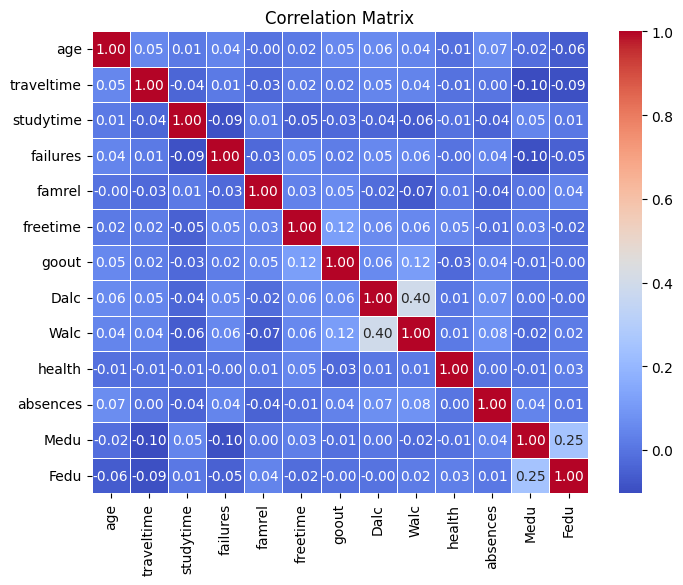

In [2]:
X_cate = df_train.iloc[:, :-1]
y_cate = df_train.iloc[:, -1]
numeric_features = ['age', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', "Medu",  "Fedu"]
corr_matrix = X_cate[numeric_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

## 2. FAMD: Factor analysis of mixed data


I aim to separate variables that have strong correlations from those with weaker correlations using factor analysis. The plot and the column contributions table indicate that "mom's job," "internet," "address," "higher," "internet," "reason," and "school" contribute significantly to the first component and they are highly correlated. This makes sense because students living in rural areas may have restricted access to the internet.

I attempted to use the first 16 components to run the model, but it did not improve the results, so I didnot use FAMD before my model fitting process. I think this may because the first 16 components only explain 65% of the cumulative PVE.

In [3]:

import prince
numeric_features = ['age', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', "Medu",  "Fedu"]

scalerStandard = StandardScaler()
df_train[numeric_features] = scalerStandard.fit_transform(df_train[numeric_features])
# Standardize the specified features on the test data using the fitted StandardScaler
df_test[numeric_features] = scalerStandard.transform(df_test[numeric_features])

X_cate = df_train.iloc[:, :-1]
y_cate = df_train.iloc[:, -1]

# change numeric to float
X_cate[numeric_features] = X_cate[numeric_features].astype(float)

famd = prince.FAMD(
    n_components=16,
    n_iter=3,
    copy=True,
    check_input=True,
    random_state=42,
    engine="sklearn",
    handle_unknown="error"  # same parameter as sklearn.preprocessing.OneHotEncoder
)
famd = famd.fit(X_cate)
########## PVE = eigenvalues
display(famd.eigenvalues_summary[0:])
print("column contributions")
display(famd.column_contributions_.style.format('{:.0%}'))

famd.plot(
    X_cate,
    x_component=0,
    y_component=1
)

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,13.874,5.93%,5.93%
1,10.883,4.65%,10.58%
2,10.422,4.45%,15.03%
3,10.197,4.36%,19.39%
4,9.999,4.27%,23.66%
...,...,...,...
11,8.531,3.65%,50.76%
12,8.388,3.58%,54.35%
13,8.154,3.48%,57.83%


column contributions


component,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
variable,,,,,,,,,,,,,,,,
age,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%
Medu,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%
Fedu,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%
traveltime,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%
studytime,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%
failures,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%
famrel,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%
freetime,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%
goout,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%


alt.LayerChart(...)

## 3. Imbalanced Data

As indicated by the barplot, this is an imbalanced dataset. There are tons of student who got grade = 2, and there are much less students who got grage = 6. I did try to implement the oversampling strategy, but it did not help to improve the result. Even worse, the accuracy got lower. So I just abandoned oversampling.

Class=2, n=920 (37.736%)
Class=0, n=618 (25.349%)
Class=1, n=504 (20.673%)
Class=5, n=102 (4.184%)
Class=4, n=162 (6.645%)
Class=6, n=39 (1.600%)
Class=3, n=93 (3.815%)


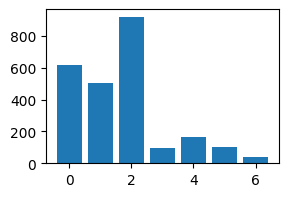

In [4]:
# label encode the target variable
y_imbalanced = LabelEncoder().fit_transform(y_cate)
# summarize distribution
counter = Counter(y_imbalanced)
for k,v in counter.items():
	per = v / len(y_imbalanced) * 100
	print('Class=%d, n=%d (%.3f%%)' % (k, v, per))
# plot the distribution
plt.figure(figsize=(3, 2))  # Adjust the figsize to make the plot smaller
plt.bar(counter.keys(), counter.values())
plt.show()

Class=2, n=920 (14.286%)
Class=0, n=920 (14.286%)
Class=1, n=920 (14.286%)
Class=5, n=920 (14.286%)
Class=4, n=920 (14.286%)
Class=6, n=920 (14.286%)
Class=3, n=920 (14.286%)


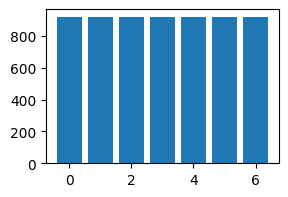

(6440, 39) (6440,)


In [5]:
cate_list = ["school",   "sex",       "address", "famsize", "Pstatus",      "Mjob",     "Fjob",    "reason", 
             "guardian", "schoolsup", "famsup",  "paid",    "activities", "nursery", "higher", "internet", "romantic"]
tr_cate_to_dummy_list = []
te_cate_to_dummy_list = []
for idx in cate_list:
    tr_cate_to_dummy_list.append(pd.get_dummies(df_train[idx],drop_first=True,prefix=idx))
    te_cate_to_dummy_list.append(pd.get_dummies(df_test[idx],drop_first=True,prefix=idx))

tr_df_dummy = pd.concat(tr_cate_to_dummy_list,axis=1)
te_df_dummy = pd.concat(te_cate_to_dummy_list,axis=1)

numeric_features = ['age', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', "Medu",    "Fedu"]

df2_train = pd.concat([tr_df_dummy, df_train[numeric_features],df_train['GRADE']], axis=1)
df2_test = pd.concat([te_df_dummy, df_test[numeric_features]], axis=1)

X = df2_train.iloc[:, :-1]
y = df2_train.iloc[:, -1]

y_imbalanced = LabelEncoder().fit_transform(y)
# transform the dataset
oversample = SMOTE()
X_imbalanced, y_balanced = oversample.fit_resample(X, y_imbalanced)

# summarize distribution
counter = Counter(y_balanced)
for k,v in counter.items():
	per = v / len(y_balanced) * 100
	print('Class=%d, n=%d (%.3f%%)' % (k, v, per))
# plot the distribution
plt.figure(figsize=(3, 2))  # Adjust the figsize to make the plot smaller
plt.bar(counter.keys(), counter.values())
plt.show()
print(X_imbalanced.shape,y_balanced.shape)

## 4. Distribution of features

The categorical variables are in skyblue, while the numeric variables are in blue. The plot indicates that the absences, failures and daily alchohol assumption is extremely right skewed. Multinomial logistic models assume that features follow a specific distribution. Skewed features might violate this assumption and could lead to biased model estimates. In the future, I will consider preprocess skewed features before fitting a multinomial logistic model using log transformation, or Box-Cox transformation.

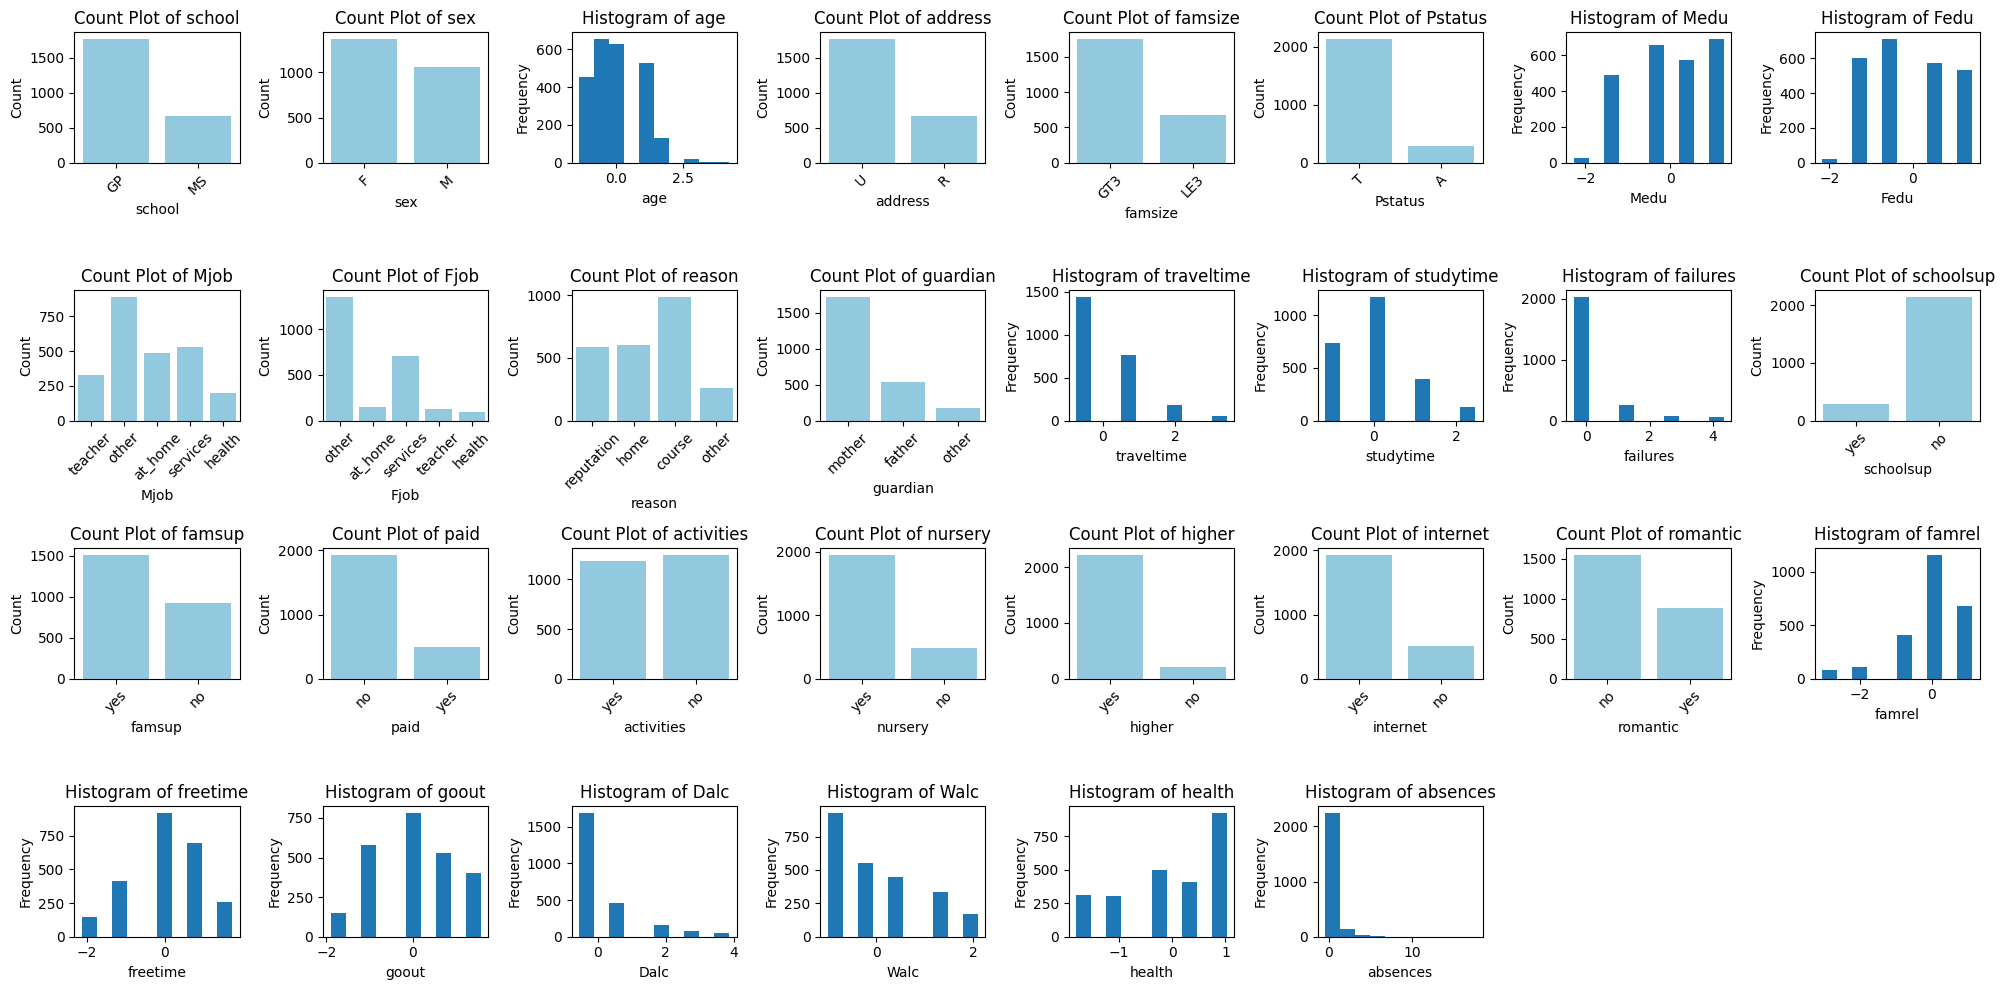

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'data' is your DataFrame containing all features
# Assuming 'X_cate' is your DataFrame containing all features

num_features = len(X_cate.columns)
num_rows = num_features // 8 + (1 if num_features % 8 != 0 else 0)  # Calculate the number of rows needed

fig, axs = plt.subplots(num_rows, 8, figsize=(20, num_rows * 2.5))

# Iterate through each feature
for i, feature in enumerate(X_cate.columns):
    row = i // 8
    col = i % 8
    ax = axs[row, col]
    
    # Check if the feature is numerical
    if X_cate[feature].dtype in ['int64', 'float64']:
        # Create histogram
        ax.hist(X_cate[feature], bins=10)  # Adjust the number of bins as needed
        ax.set_xlabel('{}'.format(feature))
        ax.set_ylabel('Frequency')
        ax.set_title('Histogram of {}'.format(feature))
    
    else:  # If the feature is categorical
        # Create count plot
        sns.countplot(x=feature, data=X_cate, ax=ax, color='skyblue')
        ax.set_xlabel('{}'.format(feature))
        ax.set_ylabel('Count')
        ax.set_title('Count Plot of {}'.format(feature))
        ax.tick_params(axis='x', labelrotation=45)


# Hide any unused subplots
for i in range(num_features, num_rows * 8):
    row = i // 8
    col = i % 8
    axs[row, col].axis('off')

plt.tight_layout()
plt.show()


# Data Engineering

## 1. Numerically encode categorical features


In [7]:
df_train =  pd.read_csv('train_data.csv') #restart
df_train
df_test = pd.read_csv('test_data.csv') 

print(df_train.shape,df_train["absences"].dtypes)
# ## To dummy & to categorical
df_train["school"] = df_train["school"].astype('category') #2
df_train["sex"] = df_train["sex"].astype('category') #3
df_train["address"] = df_train["address"].astype('category') #5
df_train["famsize"] = df_train["famsize"].astype('category') #6
df_train["Pstatus"] = df_train["Pstatus"].astype('category') #7

df_train["Mjob"] = df_train["Mjob"].astype('category') #10
df_train["Fjob"] = df_train["Fjob"].astype('category') #11
df_train["reason"] = df_train["reason"].astype('category') #12
df_train["guardian"] = df_train["guardian"].astype('category') #13
df_train["schoolsup"] = df_train["schoolsup"].astype('category') #17
df_train["famsup"] = df_train["famsup"].astype('category') #18
df_train["paid"] = df_train["paid"].astype('category') #19
df_train["activities"] = df_train["activities"].astype('category') #20
df_train["nursery"] = df_train["nursery"].astype('category') #21
df_train["higher"] = df_train["higher"].astype('category') #22
df_train["internet"] = df_train["internet"].astype('category') #23
df_train["romantic"] = df_train["romantic"].astype('category') #24

########
df_test["school"] = df_test["school"].astype('category')  # 2
df_test["sex"] = df_test["sex"].astype('category')  # 3
df_test["address"] = df_test["address"].astype('category')  # 5
df_test["famsize"] = df_test["famsize"].astype('category')  # 6
df_test["Pstatus"] = df_test["Pstatus"].astype('category')  # 7
df_test["Mjob"] = df_test["Mjob"].astype('category')  # 10
df_test["Fjob"] = df_test["Fjob"].astype('category')  # 11
df_test["reason"] = df_test["reason"].astype('category')  # 12
df_test["guardian"] = df_test["guardian"].astype('category')  # 13
df_test["schoolsup"] = df_test["schoolsup"].astype('category')  # 17
df_test["famsup"] = df_test["famsup"].astype('category')  # 18
df_test["paid"] = df_test["paid"].astype('category')  # 19
df_test["activities"] = df_test["activities"].astype('category')  # 20
df_test["nursery"] = df_test["nursery"].astype('category')  # 21
df_test["higher"] = df_test["higher"].astype('category')  # 22
df_test["internet"] = df_test["internet"].astype('category')  # 23
df_test["romantic"] = df_test["romantic"].astype('category')  # 24


cate_list = ["school",   "sex",       "address", "famsize", "Pstatus",      "Mjob",     "Fjob",    "reason", 
             "guardian", "schoolsup", "famsup",  "paid",    "activities", "nursery", "higher", "internet", "romantic"]
tr_cate_to_dummy_list = []
te_cate_to_dummy_list = []
for idx in cate_list:
    tr_cate_to_dummy_list.append(pd.get_dummies(df_train[idx],drop_first=True,prefix=idx))
    te_cate_to_dummy_list.append(pd.get_dummies(df_test[idx],drop_first=True,prefix=idx))

tr_df_dummy = pd.concat(tr_cate_to_dummy_list,axis=1)
te_df_dummy = pd.concat(te_cate_to_dummy_list,axis=1)

numeric_features = ['age', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', "Medu",    "Fedu"]

df2_train = pd.concat([tr_df_dummy, df_train[numeric_features],df_train['GRADE']], axis=1)
df2_test = pd.concat([te_df_dummy, df_test[numeric_features]], axis=1)

print(df_train[numeric_features].shape,tr_df_dummy.shape,df2_train.shape)
print(df_test[numeric_features].shape,te_df_dummy.shape,df2_test.shape)

#########################################
# tc = TargetEncoder(smooth="auto")
# X_before_encode = df_train.iloc[:,:-1]
# y_before_encode = df_train.iloc[:, -1]
# df2_train = pd.DataFrame(tc.fit_transform(X_before_encode,y_before_encode))
# df2_train = pd.concat([df2_train,df_train['GRADE']], axis=1)

# df2_test = tc.transform(df_test)


# display(df2_train)
# display(df2_test,len(df2_test))
#################################

(2438, 31) int64
(2438, 13) (2438, 26) (2438, 40)
(610, 13) (610, 26) (610, 39)


## 2. Detect outliers
Since outliers can impact scaling, it's reasonable to remove them first. Using z-scores, I found that there were some outliers in the feature "absence." However, after removing the outliers, the model's performance did not improve.

In [8]:
numeric_columns = df_train.select_dtypes(include=['int64', 'float64']).columns

# loop over all numeric varaibles
for column in numeric_columns:
    # calc z-score to detect if exceed threshold
    z_scores = (df_train[column] - df_train[column].mean()) / df_train[column].std()
    outliers = df_train[np.abs(z_scores) > 3]  # 假设阈值为3 @@
    if not outliers.empty:
        # print('#######outlier',column)
        # display(pd.concat([outliers[column],outliers["GRADE"]],axis=1))
        if column == 'absences':
            print('#######outlier',column)
            display(pd.concat([outliers[column],outliers["GRADE"]],axis=1))
            outlier_indices = outliers.index
            print('Indices of outliers in absences:', outlier_indices.tolist())
# df_train_without_outliers = df_train.drop(index=outlier_indices)
# df2_train_without_outliers = df2_train.drop(index=outlier_indices)

# X = df2_train_without_outliers.iloc[:, :-1]
# y = df2_train_without_outliers.iloc[:, -1]

# X = df_train_without_outliers.iloc[:, :-1]
# y = df_train_without_outliers.iloc[:, -1]
# print(df_train.shape, df_train_without_outliers.shape)

#######outlier absences


,absences,GRADE
108,18,4
168,20,3
207,40,2
249,16,1
255,15,1
...,...,...
2118,16,1
2154,26,0
2159,16,2
2205,16,2


Indices of outliers in absences: [108, 168, 207, 249, 255, 276, 347, 408, 491, 525, 546, 549, 557, 642, 678, 714, 732, 741, 752, 808, 831, 1071, 1115, 1237, 1387, 1510, 1544, 1550, 1561, 1564, 1568, 1585, 1608, 1673, 1682, 1709, 1733, 1783, 1794, 1826, 1859, 1880, 1940, 1964, 2118, 2154, 2159, 2205, 2343]


## 3. Scale quantitative features 

| **Algorithms that Require Feature Scaling** | **Algorithms that Do Not Require Feature Scaling** |
|---------------------------------------------|---------------------------------------------------|
| Linear Regression (if regularized)          | Naive Bayes                                       |
| Logistic Regression (if regularized)        | Decision Tree                                     |
| KNN                                         | Random Forest                                     |
| SVM                                         | AdaBoost                                          |
| KMeans                                      | XGBoost                                           |
| Hierarchical Clustering                     |                                                   |
| Neural Networks                             |                                                   |
| PCA                                         |                                                   |


The results would vary greatly between different units, for example 5km and 5000m. **The features with high magnitudes will weigh in a lot more in the distance calculations than features with low magnitudes.** In general, algorithms that use Eucledian distance or similarities between data points, such as KNN and SVM, are sensitive to feature scaling. In this competition, I only applied feature scaling on SVM and multinomial logistic regression. I did apply it on XGBoost and Other tree-based methods.

In [9]:
numeric_features = ['age', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', "Medu",  "Fedu"]
####################################################
scalerStandard = StandardScaler()
########################################

#######################
#1. no encoding + without scale
X_train, X_test, y_train, y_test = train_test_split(df_train.iloc[:, :-1], df_train.iloc[:, -1], train_size=0.8, random_state=19)
all_X_train = df_train.iloc[:, :-1]
all_y_train = df_train.iloc[:, -1]


#2. dummy + without scale
X2_train, X2_test, y2_train, y2_test = train_test_split(df2_train.iloc[:, :-1], df2_train.iloc[:, -1], train_size=0.8, random_state=19)
all_X2_train = df2_train.iloc[:, :-1]
all_y2_train = df2_train.iloc[:, -1]


#3. no encoding + with scale
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(df_train.iloc[:, :-1], df_train.iloc[:, -1], train_size=0.8, random_state=19)
X_train_scaled[numeric_features] = scalerStandard.fit_transform(X_train_scaled[numeric_features])
X_test_scaled[numeric_features] = scalerStandard.transform(X_test_scaled[numeric_features])

df_train_scaled = df_train
df_test_scaled = df_test
df_train_scaled[numeric_features] = scalerStandard.fit_transform(df_train_scaled[numeric_features])
df_test_scaled[numeric_features] = scalerStandard.transform(df_test_scaled[numeric_features])

all_X_train_scaled = df_train_scaled.iloc[:, :-1]
all_y_train_scaled = df_train_scaled.iloc[:, -1]

#4. dummy + with scale
X2_train_scaled, X2_test_scaled, y2_train_scaled, y2_test_scaled = train_test_split(df2_train.iloc[:, :-1], df2_train.iloc[:, -1], train_size=0.8, random_state=19)
X2_train_scaled[numeric_features] = scalerStandard.fit_transform(X2_train_scaled[numeric_features])
X2_test_scaled[numeric_features] = scalerStandard.transform(X2_test_scaled[numeric_features])

df2_train_scaled = df2_train
df2_test_scaled = df2_test
df2_train_scaled[numeric_features] = scalerStandard.fit_transform(df2_train_scaled[numeric_features])
df2_test_scaled[numeric_features] = scalerStandard.transform(df2_test_scaled[numeric_features])

all_X2_train_scaled = df2_train_scaled.iloc[:, :-1]
all_y2_train_scaled = df2_train_scaled.iloc[:, -1]


# Models

## Confusion matrix function

In [10]:
def plot_confusion_matrix(y_test, y_pred):
    # Compute the confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot the heatmap
    plt.figure(figsize=(4, 3))
    labels = [0, 1, 2, 3, 4, 5, 6]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix Heatmap')
    plt.show()

## 1. Multinomial Logistic Regression

0.0020
0.0030
0.0040
0.0050
0.0100
0.0120
0.0130
0.0150
0.0160
0.0190
0.0200
0.0300
>0.0020 0.380 (0.009)
>0.0030 0.381 (0.014)
>0.0040 0.384 (0.015)
>0.0050 0.383 (0.015)
>0.0100 0.383 (0.019)
>0.0120 0.383 (0.018)
>0.0130 0.383 (0.018)
>0.0150 0.382 (0.019)
>0.0160 0.382 (0.019)
>0.0190 0.382 (0.019)
>0.0200 0.382 (0.019)
>0.0300 0.381 (0.020)


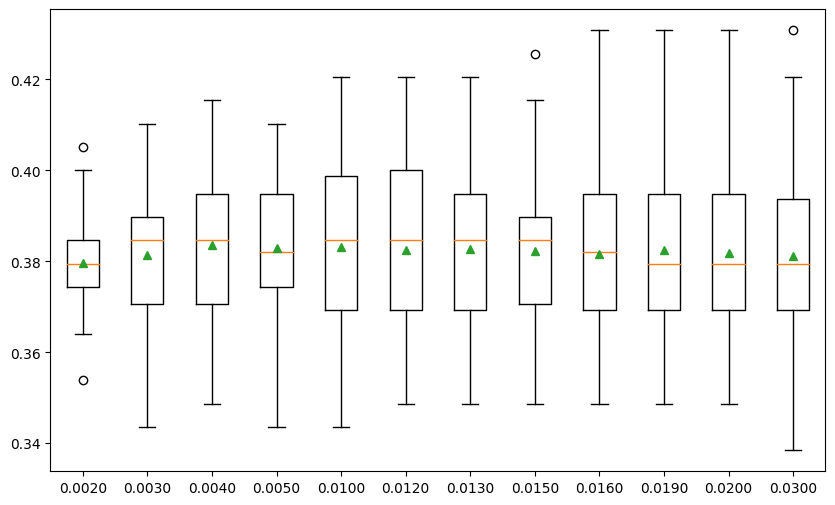

In [11]:
def get_models():
	models = dict()
	for p in [0.002,0.003,0.004,0.005, 0.01,0.012,0.013,0.015, 0.016, 0.019, 0.02, 0.03]:
		# create name for model
		key = '%.4f' % p
		print(key)
		# turn off penalty in some cases
		if p == 0.0:
			# no penalty in this case
			models[key] = LogisticRegression(multi_class='multinomial', solver='lbfgs', penalty=None)
		else:
			models[key] = LogisticRegression(multi_class='multinomial', solver='lbfgs', penalty='l2', C=p) 
	return models
 
# evaluate a give model using CV
def evaluate_model(model, X, y):
	cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=19)
	# evaluate the model
	scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
	return scores
 
models = get_models()
# evaluate the models and store results
results, names = list(), list()
plt.figure(figsize=(10, 6))

for name, model in models.items():
	# evaluate the model and collect the scores
	scores = evaluate_model(model, X2_train_scaled, y2_train_scaled)
	# store the results
	results.append(scores)
	names.append(name)
	# summarize progress along the way
	print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))
# plot model performance for comparison
plt.boxplot(results, labels=names, showmeans=True)
plt.show(); #0.01



training accuracy 0.39384615384615385
test accuracy 0.39344262295081966


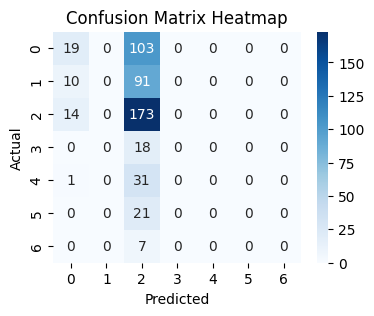

In [12]:
best_multi = LogisticRegression(multi_class='multinomial', solver='lbfgs', penalty='l2', C=0.004,max_iter=1000) #max_iter need to be larger
# print(best_multi_model)
best_multi.fit(X2_train_scaled,y2_train_scaled)
# print(fit_best_multi_model)

###########
#accuracy
print("training accuracy", best_multi.score(X2_train_scaled, y2_train_scaled))
print("test accuracy",  best_multi.score(X2_test_scaled, y2_test_scaled))
###########
#draw cm
y_pred = best_multi.predict(X2_test_scaled)
# print("report", classification_report(y_test, y_pred))
plot_confusion_matrix(y2_test_scaled,y_pred)

In [13]:
#fit the whole training set
###########
best_multi = LogisticRegression(multi_class='multinomial', solver='lbfgs', penalty='l2', C=0.004,max_iter=1000) #max_iter need to be larger
# print(best_multi_model)
best_multi.fit(all_X2_train_scaled,all_y2_train_scaled)
final_y_pred = best_multi.predict(df2_test_scaled)

## Subset selection & Multinomial regression

In [14]:
import pdb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from operator import itemgetter
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=19)

def forward_step_select(predictors, max_features=len(list(X.columns))):
    
    def process_logistic_model(features):
        """
        Constructs Logistic Regression of response onto features.
        """
        # Create design Matrix
        X_train_subset = X_train[features]
        y_train_subset = y_train

        # Fit the logistic regression model
        model = LogisticRegression(multi_class='multinomial', solver='lbfgs', penalty='l2', C=0.02, max_iter=1000)
        model.fit(X_train_subset, y_train_subset)

        # Predict on the test set
        X_test_subset = X_test[features]
        y_pred = model.predict(X_test_subset)

        # Calculate accuracy score
        accuracy = accuracy_score(y_test, y_pred)
        return (model, accuracy)

    def update_model(best_features, remaining_features):
        """
        Computes accuracy of possible new models and returns model with highest accuracy.
        """
        results = []
        for feature in remaining_features:
            results.append(process_logistic_model(best_features + [feature]))
        
        # select model with the highest accuracy
        new_model = sorted(results, key=itemgetter(1), reverse=True).pop(0)[0] # Important: sort in descending order
        new_features = best_features + [remaining_features[results.index((new_model, max(results, key=itemgetter(1))[1]))]]
        
        return new_features, new_model
    
    # Create list to hold models, model features and the remaining features to test
    models = []
    best_features = []
    remaining_features = predictors
    
    while remaining_features and len(best_features) < max_features:        
        # get best new feature set from update_model
        new_features, new_model = update_model(best_features, remaining_features)
        
        # update the best features to include the one we just found
        best_features = new_features
        remaining_features = [feature for feature in predictors if feature not in best_features]
        
        # append new_features and model so we can compare models with different features later
        models.append((new_features, new_model))
        
    return models
# Call our forward step function
# set up inputs
predictors = list(X.columns)
# predictors.remove('Salary')
# call forward_step_select
mods = forward_step_select(predictors,max_features=20)
print(mods)
# print(predictors)


[(['school_MS'], LogisticRegression(C=0.02, max_iter=1000, multi_class='multinomial')), (['school_MS', 'sex_M'], LogisticRegression(C=0.02, max_iter=1000, multi_class='multinomial')), (['school_MS', 'sex_M', 'address_U'], LogisticRegression(C=0.02, max_iter=1000, multi_class='multinomial')), (['school_MS', 'sex_M', 'address_U', 'higher_yes'], LogisticRegression(C=0.02, max_iter=1000, multi_class='multinomial')), (['school_MS', 'sex_M', 'address_U', 'higher_yes', 'Fedu'], LogisticRegression(C=0.02, max_iter=1000, multi_class='multinomial')), (['school_MS', 'sex_M', 'address_U', 'higher_yes', 'Fedu', 'Mjob_other'], LogisticRegression(C=0.02, max_iter=1000, multi_class='multinomial')), (['school_MS', 'sex_M', 'address_U', 'higher_yes', 'Fedu', 'Mjob_other', 'Pstatus_T'], LogisticRegression(C=0.02, max_iter=1000, multi_class='multinomial')), (['school_MS', 'sex_M', 'address_U', 'higher_yes', 'Fedu', 'Mjob_other', 'Pstatus_T', 'Mjob_health'], LogisticRegression(C=0.02, max_iter=1000, multi_

In [15]:
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', penalty='l2', C=0.02, max_iter=1000)
model.fit(X_train[mods[7][0]], y_train)
model.score(X_test[mods[7][0]],y_test)

0.39139344262295084

Confusion matrix

training accuracy 0.40923076923076923
test accuracy 0.38729508196721313
report               precision    recall  f1-score   support

           0       0.38      0.29      0.33       122
           1       0.36      0.05      0.09       101
           2       0.39      0.80      0.52       187
           3       0.00      0.00      0.00        18
           4       0.00      0.00      0.00        32
           5       0.00      0.00      0.00        21
           6       0.00      0.00      0.00         7

    accuracy                           0.39       488
   macro avg       0.16      0.16      0.13       488
weighted avg       0.32      0.39      0.30       488

[[ 35   3  84   0   0   0   0]
 [ 16   5  80   0   0   0   0]
 [ 31   6 149   0   1   0   0]
 [  3   0  15   0   0   0   0]
 [  4   0  28   0   0   0   0]
 [  2   0  19   0   0   0   0]
 [  0   0   7   0   0   0   0]]


C:\Users\17327\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\17327\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\17327\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classificati

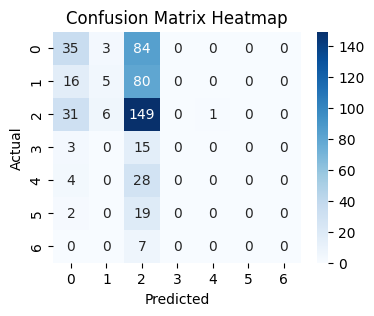

In [16]:
best_multi = LogisticRegression(multi_class='multinomial', solver='lbfgs', penalty='l2', C=0.02,max_iter=1000) #max_iter need to be larger
# print(best_multi_model)
best_multi.fit(X_train,y_train)
# print(fit_best_multi_model)

###########
#accuracy
print("training accuracy", best_multi.score(X_train, y_train))
print("test accuracy",  best_multi.score(X_test, y_test))

###########
final_y_pred = best_multi.predict(df2_test)
# print(final_y_pred)
###########

#draw cm
y_pred = best_multi.predict(X_test)
print("report", classification_report(y_test, y_pred))

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)
# print(y_test.value_counts())
print(cm)
# Plot the heatmap
plt.figure(figsize=(4, 3))
labels = [0,1,2,3,4,5,6]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()


## 2. Tree-based Methods

### 2.1 Classificaiton tree with optuna

Predict all values to be 2. 可以不用create dummy!!

In [17]:
#optuna
import optuna
from sklearn.tree import DecisionTreeClassifier

def objective(trial):
    # define search space
    max_depth = trial.suggest_int('max_depth', 1, 50)
    clf = DecisionTreeClassifier(max_depth=max_depth, random_state=19)
    # evaluate model
    score = cross_val_score(clf, X_train, y_train, cv=10, scoring='accuracy').mean()
    return score


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print("Best parameter (max_depth):", study.best_params)
print("Best cross-validation score:", study.best_value)

# use best hyper to fit
best_max_depth = study.best_params['max_depth']
best_dtclf = DecisionTreeClassifier(max_depth=best_max_depth, random_state=19)
best_dtclf.fit(X_train, y_train)

print("Training accuracy:", best_dtclf.score(X_train, y_train))
print("Test accuracy:", best_dtclf.score(X_test, y_test))


C:\Users\17327\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2024-06-08 13:56:18,634] A new study created in memory with name: no-name-1bd66f76-1acf-46fe-a164-1c40d333c439
[I 2024-06-08 13:56:18,732] Trial 0 finished with value: 0.3517948717948718 and parameters: {'max_depth': 7}. Best is trial 0 with value: 0.3517948717948718.
[I 2024-06-08 13:56:18,895] Trial 1 finished with value: 0.29128205128205126 and parameters: {'max_depth': 45}. Best is trial 0 with value: 0.3517948717948718.
[I 2024-06-08 13:56:19,039] Trial 2 finished with value: 0.3153846153846154 and parameters: {'max_depth': 12}. Best is trial 0 with value: 0.3517948717948718.
[I 2024-06-08 13:56:19,191] Trial 3 finished with value: 0.291282

Best parameter (max_depth): {'max_depth': 1}
Best cross-validation score: 0.3758974358974359
Training accuracy: 0.3758974358974359
Test accuracy: 0.3831967213114754


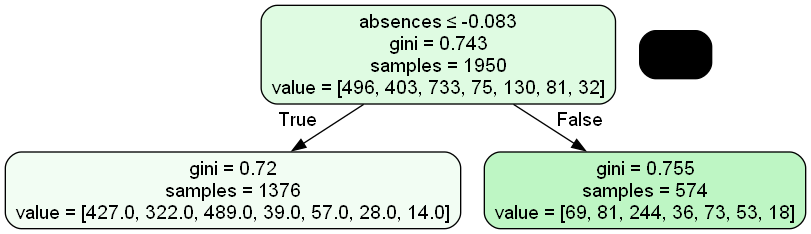

In [18]:
dot_data = StringIO()
export_graphviz(best_dtclf, out_file=dot_data, feature_names=X2_train.columns, filled=True, rounded=True, special_characters=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

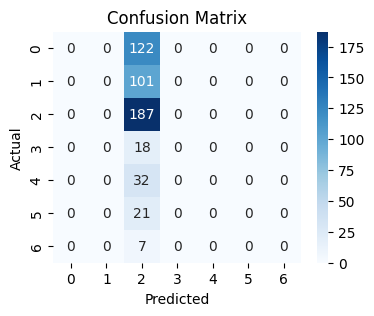

In [19]:
#draw cm
y_pred = best_dtclf.predict(X2_test)
# Compute the confusion matrix
cm = confusion_matrix(y2_test, y_pred)
# print(y_test.value_counts())
# Plot the heatmap
plt.figure(figsize=(4, 3))
labels = [0,1,2,3,4,5,6]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [143]:
#fit the test data
best_dtclf = DecisionTreeClassifier(max_depth=best_max_depth, random_state=19)
best_dtclf.fit(all_X2_train,all_y2_train)
final_y_pred = best_dtclf.predict(df2_test)

### 2.2 Bagging

In [109]:
# Bagging: using all features m=p, model feature
regr1 = RandomForestClassifier(max_features=len(X_train.columns), random_state=19) # len(X_train.columns)=13
regr1.fit(X_train, y_train)
#@@CV

RandomForestClassifier(max_features=45, random_state=1)

In [146]:
#optuna
def objective(trial):
    # define search space
    max_depth = trial.suggest_int('max_depth', 1, 50)
    clf = RandomForestClassifier(max_depth=max_depth, max_features=len(X2_train.columns), random_state=19)
    # evaluate model
    score = cross_val_score(clf, X2_train, y2_train, cv=10, scoring='accuracy').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print("Best parameter (max_depth):", study.best_params)
print("Best cross-validation score:", study.best_value)

# use best hyper to fit
best_max_depth = study.best_params['max_depth']
best_bagging = DecisionTreeClassifier(max_depth=best_max_depth, random_state=19)
best_bagging.fit(X2_train, y2_train)

print("Training accuracy:", best_bagging.score(X2_train, y2_train))
print("Test accuracy:", best_bagging.score(X2_test, y2_test))


[I 2024-06-03 21:20:37,451] A new study created in memory with name: no-name-8721b842-dcf4-485a-8b15-f589562b968d
[I 2024-06-03 21:20:45,618] Trial 0 finished with value: 0.36307692307692313 and parameters: {'max_depth': 44}. Best is trial 0 with value: 0.36307692307692313.
[I 2024-06-03 21:20:53,205] Trial 1 finished with value: 0.35897435897435903 and parameters: {'max_depth': 23}. Best is trial 0 with value: 0.36307692307692313.
[I 2024-06-03 21:21:00,628] Trial 2 finished with value: 0.36615384615384616 and parameters: {'max_depth': 18}. Best is trial 2 with value: 0.36615384615384616.
[I 2024-06-03 21:21:08,277] Trial 3 finished with value: 0.36307692307692313 and parameters: {'max_depth': 27}. Best is trial 2 with value: 0.36615384615384616.
[I 2024-06-03 21:21:13,634] Trial 4 finished with value: 0.3764102564102564 and parameters: {'max_depth': 9}. Best is trial 4 with value: 0.3764102564102564.
[I 2024-06-03 21:21:21,771] Trial 5 finished with value: 0.36307692307692313 and par

Best parameter (max_depth): {'max_depth': 5}
Best cross-validation score: 0.39282051282051283
Training accuracy: 0.42923076923076925
Test accuracy: 0.38114754098360654


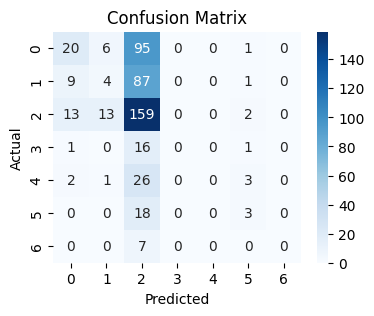

In [153]:
#draw cm
best_bagging = DecisionTreeClassifier(max_depth=best_max_depth, random_state=19)
best_bagging.fit(X2_train, y2_train)
y_pred = best_bagging.predict(X2_test)
# Compute the confusion matrix
cm = confusion_matrix(y2_test, y_pred)
# print(y_test.value_counts())
# Plot the heatmap
plt.figure(figsize=(4, 3))
labels = [0,1,2,3,4,5,6]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [154]:
#fit the test data
best_bagging.fit(all_X2_train,all_y2_train)
final_y_pred = best_dtclf.predict(df2_test)

### 2.3 Random Forest

CV

In [157]:
#optuna
def objective(trial):
    # define search space
    max_depth = trial.suggest_int('max_depth', 1, 50)
    max_features = trial.suggest_int('max_features', 1, 39)
    clf = RandomForestClassifier(max_depth=max_depth, max_features=max_features, random_state=19)
    # evaluate model
    score = cross_val_score(clf, X2_train, y2_train, cv=10, scoring='accuracy').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best parameter (max_depth):", study.best_params)
print("Best cross-validation score:", study.best_value)

# use best hyper to fit
best_max_depth = study.best_params['max_depth']
best_max_features = study.best_params['max_features']
best_RF = DecisionTreeClassifier(max_depth=best_max_depth,max_features=best_max_features, random_state=19)
best_RF.fit(X2_train, y2_train)

print("Training accuracy:", best_bagging.score(X2_train, y2_train))
print("Test accuracy:", best_bagging.score(X2_test, y2_test))


[I 2024-06-03 21:34:49,280] A new study created in memory with name: no-name-1b787898-febb-4578-b323-fc22931d623f
[I 2024-06-03 21:34:52,090] Trial 0 finished with value: 0.37230769230769234 and parameters: {'max_depth': 43, 'max_features': 5}. Best is trial 0 with value: 0.37230769230769234.
[I 2024-06-03 21:35:00,165] Trial 1 finished with value: 0.36307692307692313 and parameters: {'max_depth': 38, 'max_features': 39}. Best is trial 0 with value: 0.37230769230769234.
[I 2024-06-03 21:35:07,292] Trial 2 finished with value: 0.3712820512820513 and parameters: {'max_depth': 47, 'max_features': 31}. Best is trial 0 with value: 0.37230769230769234.
[I 2024-06-03 21:35:12,145] Trial 3 finished with value: 0.3769230769230769 and parameters: {'max_depth': 8, 'max_features': 37}. Best is trial 3 with value: 0.3769230769230769.
[I 2024-06-03 21:35:15,418] Trial 4 finished with value: 0.3625641025641026 and parameters: {'max_depth': 33, 'max_features': 9}. Best is trial 3 with value: 0.3769230

Best parameter (max_depth): {'max_depth': 8, 'max_features': 14}
Best cross-validation score: 0.3984615384615385
Training accuracy: 0.42205128205128206
Test accuracy: 0.42008196721311475


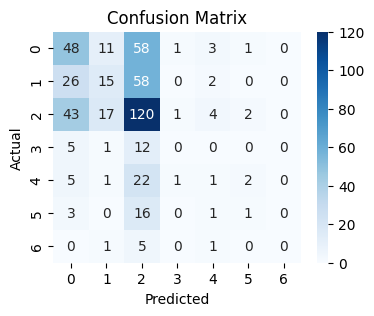

In [158]:
#draw cm
y_pred = best_RF.predict(X2_test)
# Compute the confusion matrix
cm = confusion_matrix(y2_test, y_pred)
# print(y_test.value_counts())
# Plot the heatmap
plt.figure(figsize=(4, 3))
labels = [0,1,2,3,4,5,6]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [164]:
#fit the test data
best_RF.fit(all_X2_train,all_y2_train)
final_y_pred = best_RF.predict(df2_test)

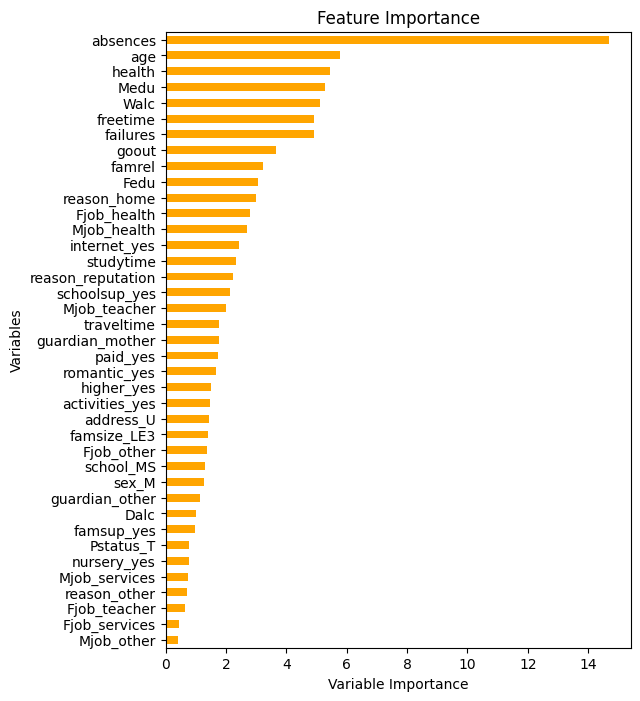

In [161]:
fig, ax = plt.subplots(figsize=(6, 8))
Importance = pd.DataFrame({'Importance':best_RF.feature_importances_*100}, index=X.columns)
Importance.sort_values(by='Importance', axis=0, ascending=True).plot(kind='barh', color='orange', ax=ax)

plt.xlabel('Variable Importance')
plt.ylabel('Variables')
plt.title('Feature Importance')

plt.gca().legend_ = None
plt.show()

### 2.4 Boosting

This training speed is so slow. It took me 1 hour to run 10 iterations. So I just randomly picked some values for the hyperparameters and report the results in the Model evaluation section.

In [167]:
#optuna
def objective(trial):
    # define search space
    max_depth = trial.suggest_int('max_depth', 1, 10) #不要太大，d=1都很好
    # max_features = trial.suggest_int('max_features', 1, 39)
    learning_rate = learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    clf = GradientBoostingClassifier(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth, random_state=19)
    # evaluate model
    score = cross_val_score(clf, X2_train, y2_train, cv=10, scoring='accuracy').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best parameter (max_depth):", study.best_params)
print("Best cross-validation score:", study.best_value)

# use best hyper to fit
best_max_depth = study.best_params['max_depth']
# best_max_features = study.best_params['max_features']
best_n_estimators = study.best_params['max_features']
best_lr = study.best_params['learning_rate']
best_boost = GradientBoostingClassifier(n_estimators=best_n_estimators, learning_rate=best_lr, max_depth=best_max_depth, random_state=19)
best_boost.fit(X2_train, y2_train)

print("Training accuracy:", best_boost.score(X2_train, y2_train))
print("Test accuracy:", best_boost.score(X2_test, y2_test))


[I 2024-06-03 21:46:41,813] A new study created in memory with name: no-name-cf175ac0-acdc-48de-8301-e9017dcb763a


[I 2024-06-03 21:49:06,189] Trial 0 finished with value: 0.3441025641025641 and parameters: {'max_depth': 13, 'learning_rate': 0.21689968526848188, 'n_estimators': 64}. Best is trial 0 with value: 0.3441025641025641.
[I 2024-06-03 21:49:46,691] Trial 1 finished with value: 0.33641025641025646 and parameters: {'max_depth': 4, 'learning_rate': 0.19034092784064077, 'n_estimators': 177}. Best is trial 0 with value: 0.3441025641025641.
[I 2024-06-03 21:53:23,755] Trial 2 finished with value: 0.3266666666666667 and parameters: {'max_depth': 16, 'learning_rate': 0.15893369049088665, 'n_estimators': 83}. Best is trial 0 with value: 0.3441025641025641.
[I 2024-06-03 21:58:37,639] Trial 3 finished with value: 0.34820512820512817 and parameters: {'max_depth': 10, 'learning_rate': 0.06629797510485021, 'n_estimators': 222}. Best is trial 3 with value: 0.34820512820512817.
[I 2024-06-03 22:02:09,828] Trial 4 finished with value: 0.32666666666666666 and parameters: {'max_depth': 26, 'learning_rate': 

KeyboardInterrupt: 

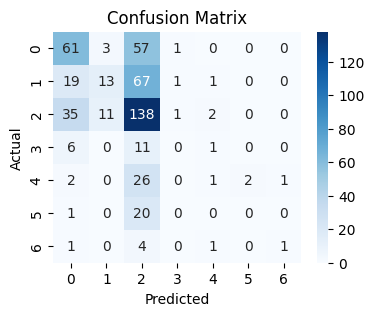

In [196]:
#draw cm
best_boost = GradientBoostingClassifier(n_estimators=500, learning_rate=0.01, max_depth=3, random_state=19)
best_boost.fit(X2_train,y2_train)
y_pred = best_boost.predict(X2_test)
# Compute the confusion matrix
cm = confusion_matrix(y2_test, y_pred)
# print(y_test.value_counts())
# Plot the heatmap
plt.figure(figsize=(4, 3))
labels = [0,1,2,3,4,5,6]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [197]:
print("Training accuracy:", best_boost.score(X2_train, y2_train))
print("Test accuracy:", best_boost.score(X2_test, y2_test))

Training accuracy: 0.5492307692307692
Test accuracy: 0.4385245901639344


In [198]:
#fit the test data
best_boost.fit(all_X2_train,all_y2_train)
final_y_pred = best_boost.predict(df2_test)

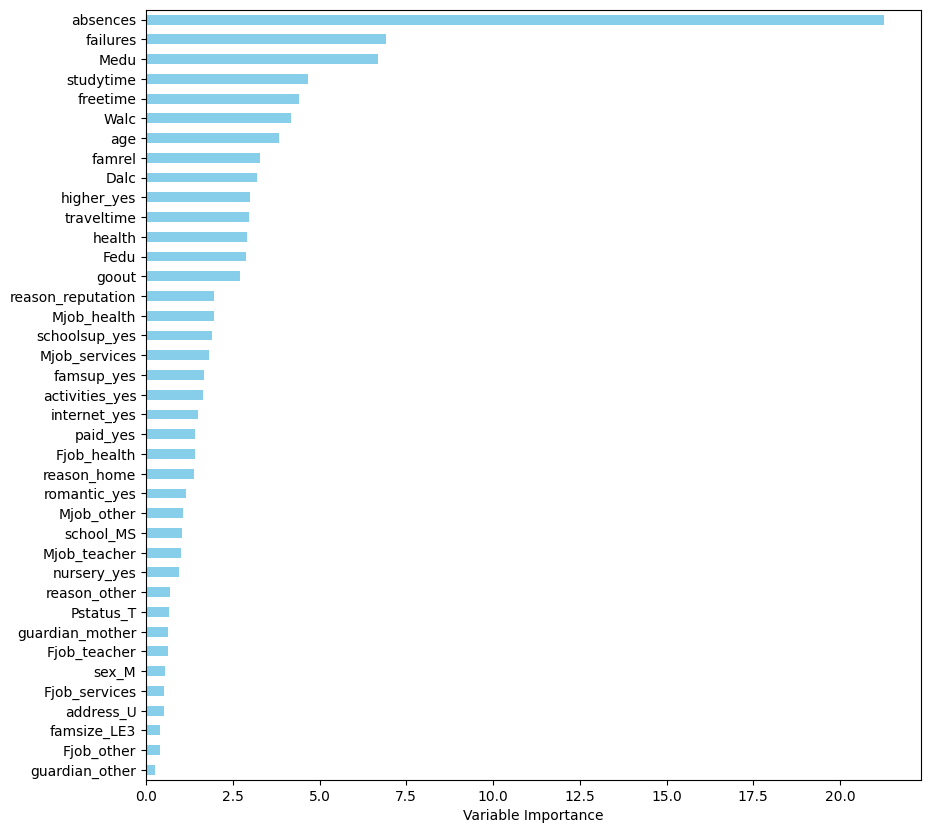

In [199]:
fig, ax = plt.subplots(figsize=(10, 10))
feature_importance = best_boost.feature_importances_*100
rel_imp = pd.Series(feature_importance, index=X.columns).sort_values(inplace=False)
rel_imp.T.plot(kind='barh', color='skyblue', )
plt.xlabel('Variable Importance')
plt.gca().legend_ = None

### 2.5 XGBoost

XGBoost (Extreme Gradient Boosting) is an optimized implementation of the gradient boosting algorithm. Compared with boosting, XGBoost uses a more regularized model formalization to control overfitting. The objective function of XGBoost includes a regularization term, resulting in better performance. The highest score I achieved in this competition was with XGBoost. I recall setting the `n_iter` parameter in `BayesSearchCV()` to 100 and running the model for 20 minutes, which yielded a public score of 0.43934 and a private score of 0.43934. At that time, I had not yet started feature engineering, so I only used Target Encoder in the pipeline function. However, after submitting the results, I realized I had forgotten to take a screenshot of the hyperparameters. This serves as a reminder to be careful about taking screenshots, as they are crucial for interpreting why a model outperforms others.      

From the model that achieved a private score of 0.42295, the hyperparameters such as lambda, subsample, and colsample_bytree deviated from their default value of 1. This indicates that the model is regularized and less likely to overfit. However, the model tends to overfit when the max_depth exceeds 13. In practice, I found it challenging to determine the optimal number of iterations (n_iter) in BayesSearchCV(pipe, search_space, cv=10, n_iter=30, random_state=9) because training the model takes time, and the hyperparameters varied significantly with different n_iter values.

  

#### Hyperparameter tuning
I learned the meaning of hyperparameters and how to tune the parameter from the documentation of XGBoost pacakge (https://xgboost.readthedocs.io/en/latest/tutorials/param_tuning.html), this video (https://www.youtube.com/watch?v=AvWfL1Us3Kg) and this blog about optuna (https://forecastegy.com/posts/xgboost-hyperparameter-tuning-with-optuna/)

| Hyperparameter | Default - Range | If increase | Type |
|----------------|-----------------|-------------|------|
| max_depth | 6 - (2,30) (0 = no limit on depth)| overfit | control model complexity | 
| **min_child_weight** | 1 - (0.1,1) | regularize | control model complexity | 
| **clf__reg_alpha** | 0 - | L1 regularize | control model complexity | 
| **clf__reg_lambda** | 1 - | L2 regularize | control model complexity | 
| gamma | 1 - (0.1,1) | overfit | control model complexity | 
|  |  |  |
| subsample | 1- (0.5,1) | overfit, if reduce -> regularize | add randomness -> training robust to noise |
| colsample_bytree | 1 - (0.1,1) | overfit |add randomness -> training robust to noise |
| colsample_bylevel | 1 - (0.1,1) | overfit |add randomness -> training robust to noise |
|  |  |  |
| n_estimators | 100 - (10,1000) | lower training speed, better | sequencially boost next tree |
| learning_rate | 0.3 - (10,1000) | fast training speed / cannot converge | |


In [173]:
from sklearn.preprocessing import OneHotEncoder

# encoder = OneHotEncoder(drop='if_binary',handle_unknown='ignore') 

estimators = [
    ('encoder',TargetEncoder()), #pre process: transform cate 
    # ('encoder', encoder), # pre-process: transform categorical features
    # ('reduce_dim', PCA()),
    ('clf', XGBClassifier()) 
]

pipe = Pipeline(steps = estimators)
pipe


Pipeline(steps=[('encoder', TargetEncoder()),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               gamma=None, gpu_id=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=None,
                               max_leaves=None, min_child_weight=None,
                               missing=nan, monotone_constraints=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, predictor=None,
                               random_state=None, reg_alpha=None,
                               reg_lambda=None, ...))])

In [212]:
search_space={
'clf__max_depth':Integer(2,20), #increase -> overfit
'clf__min_child_weight': Real(1,20),
'clf__reg_alpha':Real(1, 10.0), #L1
'clf__reg_lambda': Real(1, 10.0), #L2
'clf__gamma':Real(0.0,10.0),

'clf__subsample': Real(0.3, 1), #default = 1, take parts of data for model fitting -> regulization -> generalization better
'clf__colsample_bytree':Real(0.5,1),  #default 1

'clf__colsample_bylevel':Real(0.4, 1), #default 1, for every level
'clf__colsample_bynode':Real(0.3, 1),
'clf__learning_rate':Real(0.001, 0.3, prior='log-uniform')
}
opt_xgb = BayesSearchCV(pipe, search_space, cv=10, n_iter=30, random_state=9) #@@

#### Train

In [213]:
opt_xgb.fit(X_train,y_train) #100 8 min

BayesSearchCV(cv=10,
              estimator=Pipeline(steps=[('encoder', TargetEncoder()),
                                        ('clf',
                                         XGBClassifier(base_score=None,
                                                       booster=None,
                                                       callbacks=None,
                                                       colsample_bylevel=None,
                                                       colsample_bynode=None,
                                                       colsample_bytree=None,
                                                       early_stopping_rounds=None,
                                                       enable_categorical=False,
                                                       eval_metric=None,
                                                       gamma=None, gpu_id=None,
                                                       grow_policy=None,
                                                       importance_type=None,
                                                       interaction_co...
                             'clf__max_depth': Integer(low=2, high=20, prior='uniform', transform='normalize'),
                             'clf__min_child_weight': Real(low=1, high=20, prior='uniform', transform='normalize'),
                             'clf__reg_alpha': Real(low=1, high=10.0, prior='uniform', transform='normalize'),
                             'clf__reg_lambda': Real(low=1, high=10.0, prior='uniform', transform='normalize'),
                             'clf__subsample': Real(low=0.3, high=1, prior='uniform', transform='normalize')})

In [214]:
best_params = opt_xgb.best_estimator_.get_params()
excluded_params = [
    'memory', 'steps', 'verbose','clf', 'encoder__cols', 'encoder__drop_invariant',
    'encoder__handle_missing', 'encoder__handle_unknown', 'encoder__hierarchy',
    'encoder__min_samples_leaf', 'encoder__return_df', 'encoder__smoothing', 'encoder__verbose'
]
for param, value in best_params.items():
    if param in excluded_params:
        pass
    else: 
        print(f"{param}: {value}")
        
    # print(param)
opt_xgb.best_estimator_

encoder: TargetEncoder(cols=['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob',
                    'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid',
                    'activities', 'nursery', 'higher', 'internet', 'romantic'])
clf__objective: multi:softprob
clf__use_label_encoder: False
clf__base_score: 0.5
clf__booster: gbtree
clf__callbacks: None
clf__colsample_bylevel: 0.4
clf__colsample_bynode: 1.0
clf__colsample_bytree: 0.6829989609407721
clf__early_stopping_rounds: None
clf__enable_categorical: False
clf__eval_metric: None
clf__gamma: 0.33342867003856014
clf__gpu_id: -1
clf__grow_policy: depthwise
clf__importance_type: None
clf__interaction_constraints: 
clf__learning_rate: 0.04596917992214829
clf__max_bin: 256
clf__max_cat_to_onehot: 4
clf__max_delta_step: 0
clf__max_depth: 15
clf__max_leaves: 0
clf__min_child_weight: 14.813947128696007
clf__missing: nan
clf__monotone_constraints: ()
clf__n_estimators: 100
clf__n_jobs: 0
clf__num_parallel_tree: 1
clf__predic

Pipeline(steps=[('encoder',
                 TargetEncoder(cols=['school', 'sex', 'address', 'famsize',
                                     'Pstatus', 'Mjob', 'Fjob', 'reason',
                                     'guardian', 'schoolsup', 'famsup', 'paid',
                                     'activities', 'nursery', 'higher',
                                     'internet', 'romantic'])),
                ('clf',
                 XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
                               colsample_bylevel=0.4, colsample_bynode=1.0,
                               colsample_bytree=0.682998960...
                               grow_policy='depthwise', importance_type=None,
                               interaction_constraints='',
                               learning_rate=0.04596917992214829, max_bin=256,
                               max_cat_to_onehot=4, max_delta_step=0,
                               max_depth=15, max_leaves=0,
                               min_child_weight=14.813947128696007, missing=nan,
                               monotone_constraints='()', n_estimators=100,
                               n_jobs=0, num_parallel_tree=1,
                               objective='multi:softprob', predictor='auto',
                               random_state=0, reg_alpha=1.0, ...))])

<div>
<img src="best_XGB.png" width="500"/>
</div>

evaluate model + predict

In [215]:
# opt_xgb.fit(X_train,y_train)
print(opt_xgb.best_score_)#best cv
print(opt_xgb.score(X_train, y_train))#training error
print(opt_xgb.score(X_test,y_test)) #test


0.39384615384615385
0.5323076923076923
0.45081967213114754


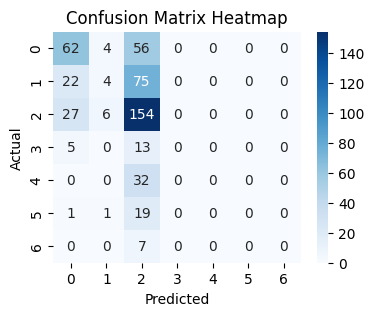

In [216]:
# Predict on the test set
# print(df_test.shape,X_test.shape)
y_pred = opt_xgb.predict(X_test)
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)
# print(X_test.value_counts())
# Plot the heatmap
plt.figure(figsize=(4, 3))
labels = [0,1,2,3,4,5,6]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()


#### Prediction of test data 

In [217]:
#fit the test data
opt_xgb.fit(all_X_train,all_y_train)
final_y_pred = opt_xgb.predict(df_test)

#### Feature importance

<AxesSubplot: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

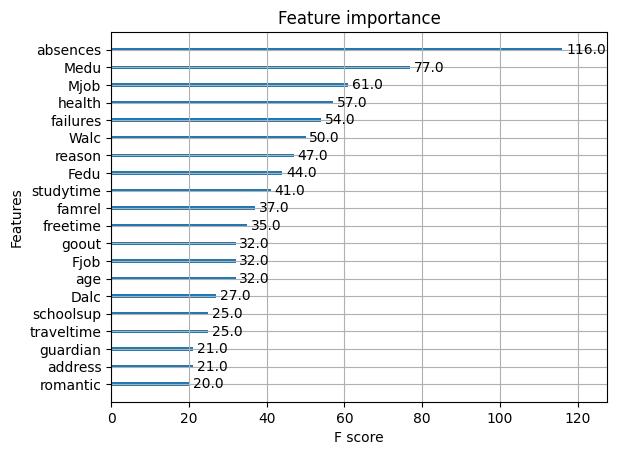

In [218]:
from xgboost import plot_importance
xgboost_step = opt_xgb.best_estimator_.steps[1]
xgboost_model = xgboost_step[1]
plot_importance(xgboost_model, max_num_features=20)

## 3. SVM (slower than XGBoost)

In [ ]:
estimators = [
    # ('encoder',TargetEncoder()), #pre process: transform cate 
    # ('reduce_dim', PCA()),
    ('clf', SVC(random_state=19))  # Change to Support Vector Machine
]
pipe = Pipeline(steps = estimators)

search_space={
    'clf__C': Real(1e-5, 1e+8, prior='log-uniform'),  # Regularization parameter
    'clf__kernel': Categorical([ 'rbf', 'sigmoid']),  # Kernel type
    'clf__gamma': Real(1e-5, 1e+1, prior='log-uniform'),  # Kernel coefficient (only for rbf, poly, and sigmoid kernels)
    # 'clf__degree': Integer(1, 5),  # Polynomial degree (only for poly kernel)
}
#need to use pipeline when using bayesSearchCV
opt_svm = BayesSearchCV(pipe, search_space, cv=10, n_iter=20, random_state=19) #
opt_svm.fit(X2_train_scaled,y2_train_scaled) #100 


best_params = opt_svm.best_estimator_.get_params()
excluded_params = [
    'memory', 'steps', 'verbose','clf', 'encoder__cols', 'encoder__drop_invariant',
    'encoder__handle_missing', 'encoder__handle_unknown', 'encoder__hierarchy',
    'encoder__min_samples_leaf', 'encoder__return_df', 'encoder__smoothing', 'encoder__verbose'
]
for param, value in best_params.items():
    if param in excluded_params:
        pass
    else: 
        print(f"{param}: {value}")
    # print(param)
print(opt_svm.best_score_)#training cv


In [7]:
print(opt_svm.best_score_)#best cv
print(opt_svm.score(X2_train_scaled, y2_train_scaled))#training error
print(opt_svm.score(X2_test_scaled,y2_test_scaled)) #test

0.4112820512820513
0.382051282051282
0.38114754098360654


In [8]:
#fit the test data
final_y_pred = opt_svm.predict(df2_test_scaled)

## 4. TPOTClassifier Automatically select the best model

In [67]:
from tpot import TPOTClassifier

tpot = TPOTClassifier(generations=4, population_size=50, verbosity=2, random_state=42)


tpot.fit(X_train, y_train)


evaluated_individuals = tpot.evaluated_individuals_
sorted_individuals = sorted(evaluated_individuals.items(), key=lambda x: x[1]['internal_cv_score'], reverse=True)
for i, (model, scores) in enumerate(sorted_individuals):
    print(f"Rank {i+1}: {model} - CV score: {scores['internal_cv_score']}")


print("\n best mode:")
print(tpot.fitted_pipeline_)


tpot.export('best_model_pipeline.py')


accuracy = tpot.score(X_test, y_test)
print(f"\n acc: {accuracy}")


NameError: name 'TPOTClassifier' is not defined

## 5. Ordinal Logistic
Ordinal regression can be considered as an intermediate process of regression and classification. Since the target variable of this dataset is ordered, I tried Ordinal logistic regression.

In [209]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=9)

mod_prob = OrderedModel(y_train,X2_train_scaled,
                        distr='probit')
res_prob = mod_prob.fit(method='bfgs')
# res_prob.summary()
predicted = res_prob.model.predict(res_prob.params, exog=X_test[mods[6][0]])
predicted_test = res_prob.model.predict(res_prob.params, exog=df2_test[mods[6][0]])

Optimization terminated successfully.
         Current function value: 1.527088
         Iterations: 30
         Function evaluations: 31
         Gradient evaluations: 31


In [210]:
max_indices = []
for sublist in predicted:
    max_index = np.argmax(sublist)
    max_indices.append(max_index)
print(max_indices)
print(accuracy_score(y_test, max_indices))

max_indices = []
for sublist in predicted_test:
    max_index = np.argmax(sublist)
    max_indices.append(max_index)
print(max_indices)
print(len(max_indices))


[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 

# Model Evaluation and Hyperparameters Tuning Methods

Tuning Methods: I used RepeatedStratifiedKFold to tune the C parameter in the multinomial logistic regression model, Optuna to tune the hyperparameters in the tree-based methods, and BayesSearchCV to tune the hyperparameters in XGBoost and SVM.  Among all of these methods, I found BayesSearchCV to be the easiest to implement because it allowed for efficient exploration of the hyperparameter space while automatically adjusting the search based on previous evaluations. This adaptive search capability streamlined the tuning process, requiring less manual intervention compared to other methods.          

Tuning Speed: The tuning speed for SVM using BayesSearchCV is much slower than that of XGBoost. For the boosting model, since it took me 1 hour to run 10 iterations using Optuna, I randomly selected some values for the hyperparameters and am reporting the results here. It turned out that if the `max_depth` is not too large, the model tends not to overfit, and the model performance is quite good.

Feature importance in tree-based models: In all tree-based methods, as indicated by the photo above. the feature **absences** consistently rank first in the feature importance plot. This indicates that the absence or presence of certain features has a significant impact on the model's predictions. Additionally, the feature "Medu" consistently ranks at the very top in terms of importance. This suggests that the mother's education level plays a crucial role in determining target variable in the dataset. 

SVM: At the very beginning, I forgot the scale the data before using SVM, and I only attained public score that is lower than 0.4. However, the public score and private score got better after I normalize the data.




| **Algorithm**      | **Best CV Accuracy** | **Train Accuracy** | **Test Accuracy** | **Public Score** | **Private Score** | **Hyperparameters**            |
|--------------------|----------------------|--------------------|-------------------|------------------|-------------------|-------------------------------|
| 1. Multinomial     | 0.384                | 0.3938             | 0.3934            | 0.42295          | 0.4               | C = 0.004                     |       
| 2.1 Classification tree| 0.3758           | 0.3759             | 0.3831            | 0.40983          | 0.378             | max-depth = 1 |
| 2.2 Bagging        | 0.3928               | 0.4292             |0.3814            | 0.3836           |0.35737            | max-depth = 5 |
| 2.3 Random Forest  | 0.3985               | 0.4221          | 0.42                 | 0.3738              |0.3607          | max-depth = 8, max-feature = 14 |
| 2.4 Boosting (no tuning)|                  | 0.5492           |0.4385         |    0.40625              | 0.42622           |  See model above|
| 2.5 XGBoost        | 0.3919               | 0.4038             |                   |0.42262           |0.42295            | See picture above             |
| 3. SVM             | 0.3821                |0.4113             |0.3811             |0.41967           |0.40327            |  C=1000000        |




# Export predicted result 

In [9]:
from collections import Counter

id_list = list(range(610))

predictions_df = pd.DataFrame({'ID': id_list, 'GRADE': final_y_pred})
predictions_df.to_csv('svm.csv', index=False)
# print(final_y_pred,type(final_y_pred))

count = Counter(final_y_pred)
total_count = len(final_y_pred)
percentage = {key: (value / total_count) * 100 for key, value in count.items()}

print("Counts:", count)
print("Percent:", percentage) #485, 117, 8

Counts: Counter({2: 472, 0: 138})
Percent: {2: 77.37704918032787, 0: 22.62295081967213}


# Future Improvement

The dataset has very skewed distributions, and multinomial logistic models assume that features follow a specific distribution. Skewed features might violate this assumption, potentially leading to biased model estimates. In the future, I will consider preprocessing skewed features before fitting a multinomial logistic model using log transformation or Box-Cox transformation.

For this project, I only tried target encoding and dummy encoding. In the future, I may explore different encoding techniques.

Additionally, since manually inspecting different models is time-consuming and prone to errors, I plan to use AutoML in the future to automate the model selection process.

# References        
1. FAMD. https://www.youtube.com/watch?v=Ollp2nSQCLY & https://maxhalford.github.io/prince/famd/
2. Ordinal regression: https://analyticsindiamag.com/a-complete-tutorial-on-ordinal-regression-in-python/
3. Encoding: https://www.analyticsvidhya.com/blog/2020/08/types-of-categorical-data-encoding/
4. MinMax vs Standardize: https://www.cnblogs.com/GouQ/p/11840653.html 
5. XGBoost: https://xgboost.readthedocs.io/en/latest/tutorials/param_tuning.html
6. XGBoost: https://www.youtube.com/watch?v=AvWfL1Us3Kg
7. Optuna: https://forecastegy.com/posts/xgboost-hyperparameter-tuning-with-optuna/
8. TPOTClassifier: https://towardsdatascience.com/tpot-automated-machine-learning-in-python-4c063b3e5de9 